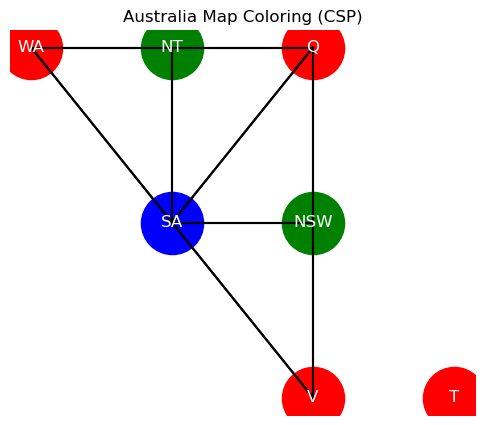

In [6]:
import matplotlib.pyplot as plt

states = ['WA','NT','SA','Q','NSW','V','T']

neighbors = {
    'WA': ['NT','SA'],
    'NT': ['WA','SA','Q'],
    'SA': ['WA','NT','Q','NSW','V'],
    'Q': ['NT','SA','NSW'],
    'NSW': ['Q','SA','V'],
    'V': ['SA','NSW'],
    'T': []
}

colors = ['red','green','blue']

def is_valid(state, color, assignment):
    for n in neighbors[state]:
        if n in assignment and assignment[n] == color:
            return False
    return True

def backtrack(assignment):
    if len(assignment) == len(states):
        return assignment
    unassigned = [s for s in states if s not in assignment][0]
    for color in colors:
        if is_valid(unassigned, color, assignment):
            assignment[unassigned] = color
            result = backtrack(assignment)
            if result:
                return result
            del assignment[unassigned]
    return None

solution = backtrack({})

positions = {
    'WA': (0,2),
    'NT': (1,2),
    'SA': (1,1),
    'Q': (2,2),
    'NSW': (2,1),
    'V': (2,0),
    'T': (3,0)
}

plt.figure(figsize=(6,5))

for state, (x,y) in positions.items():
    plt.scatter(x, y, s=2000, color=solution[state])
    plt.text(x, y, state, ha='center', va='center', fontsize=12, color='white')

for state in states:
    for neighbor in neighbors[state]:
        x1, y1 = positions[state]
        x2, y2 = positions[neighbor]
        plt.plot([x1,x2],[y1,y2],'k-')

plt.title("Australia Map Coloring (CSP)")
plt.axis('off')
plt.show()